In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
@torch.no_grad()
def evaluate_model(model, loader, class_names, model_name="Model", device=None):
    device = device or next(model.parameters()).device
    model.eval()

    all_logits, all_targets = [], []
    for imgs, targets in loader:
        imgs = imgs.to(device, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=device.type == "cuda"):
            out = model(imgs)
        all_logits.append(out.float().cpu())
        all_targets.append(targets)
    logits  = torch.cat(all_logits)
    targets = torch.cat(all_targets)

    pred_idx = logits.argmax(1)
    y_probs  = torch.softmax(logits, dim=1).numpy()

    top1 = 100.0 * pred_idx.eq(targets).float().mean().item()
    top5_hit = logits.topk(5, dim=1).indices.eq(targets.unsqueeze(1)).any(dim=1)
    top5 = 100.0 * top5_hit.float().mean().item()

    y_true = targets.numpy()
    y_pred = pred_idx.numpy()

    num_classes = len(class_names)
    per_class_acc = np.zeros(num_classes)
    for c in range(num_classes):
        mask = y_true == c
        if mask.sum() > 0:
            per_class_acc[c] = 100.0 * (y_pred[mask] == c).mean()

    report = classification_report(y_true, y_pred, target_names=class_names,
                                    digits=3, zero_division=0)

    print(f"\n{'='*60}\n{model_name}\n{'='*60}")
    print(f"Top-1 accuracy: {top1:.2f}%   Top-5 accuracy: {top5:.2f}%")
    worst = np.argsort(per_class_acc)[:5]
    best  = np.argsort(per_class_acc)[-5:][::-1]
    print("Weakest classes:", ", ".join(f"{class_names[i]} ({per_class_acc[i]:.0f}%)" for i in worst))
    print("Strongest classes:", ", ".join(f"{class_names[i]} ({per_class_acc[i]:.0f}%)" for i in best))

    return {
        "model_name": model_name,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_probs": y_probs,
        "top1": top1,
        "top5": top5,
        "per_class_acc": per_class_acc,
        "report": report,
    }

In [4]:
def plot_training_curves(history, model_name="Model"):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    axes[0].plot(epochs, history["train_loss"], label="Train")
    axes[0].plot(epochs, history["val_loss"], label="Val")
    axes[0].set_title(f"{model_name} — Loss")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, history["train_acc"], label="Train (mixed)", alpha=0.6)
    axes[1].plot(epochs, history["val_acc"], label="Val")
    if history.get("clean_train_acc"):
        ct_epochs = sorted(history["clean_train_acc"].keys())
        ct_vals = [history["clean_train_acc"][e] for e in ct_epochs]
        axes[1].plot(ct_epochs, ct_vals, "o--", label="Train (clean probe)", color="green")
    axes[1].set_title(f"{model_name} — Accuracy")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
    axes[1].legend(); axes[1].grid(alpha=0.3)

    fig.tight_layout()
    plt.show()

In [5]:
def plot_confusion_matrix(y_true, y_pred, class_names, model_name="Model",
                           normalize=True, figsize=(12, 12)):
    cm = confusion_matrix(y_true, y_pred, labels=range(len(class_names)))
    if normalize:
        cm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(cm, cmap="viridis")
    n = len(class_names)
    if n <= 20:          # 100+ classes → labels unreadable, skip them
        ax.set_xticks(range(n)); ax.set_xticklabels(class_names, rotation=90, fontsize=7)
        ax.set_yticks(range(n)); ax.set_yticklabels(class_names, fontsize=7)
    else:
        ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(f"{model_name} — Confusion Matrix" + (" (row-normalized)" if normalize else ""))
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    plt.show()
    return cm

In [ ]:
"""
CIFAR-100 → PCA-initialized ResNet-18 (fully trainable) → ~80% val accuracy
===========================================================================
Recipe (standard strong CIFAR-100 setup):
  • PCA-initialized 5×5 stem (64 filters from 5×5×3 colour patches)
  • ResNet-18 (CIFAR variant: 3×3-friendly stem, no max-pool)
  • Per-channel normalization (missing in the previous run!)
  • SGD + Nesterov, lr 0.1, cosine schedule, weight decay 5e-4
  • RandAugment + RandomErasing + Mixup/CutMix (mixing OFF for last 15 epochs)
  • Label smoothing 0.1, AMP for speed, batch 128
  • Clean train-accuracy probe every 10 epochs (mixup makes the running
    train metric meaningless — this gives you the real number)

"""

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
import numpy as np
import random, math, time

# ─────────────────────────────────────────────
#  0.  DEVICE / SEED
# ─────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Using device: {device}")
if device.type == "cuda":
    print(f"[INFO] GPU : {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)

# ─────────────────────────────────────────────
#  HYPER-PARAMETERS
# ─────────────────────────────────────────────
NUM_CLASSES   = 100
BATCH_SIZE    = 128
EPOCHS        = 200
NO_MIX_LAST   = 15          # disable mixup/cutmix for the final N epochs
BASE_LR       = 0.1
WEIGHT_DECAY  = 5e-4
LABEL_SMOOTH  = 0.1
WARMUP_EPOCHS = 5

MIX_PROB      = 0.5
MIXUP_ALPHA   = 0.2
CUTMIX_ALPHA  = 1.0

STEM_K        = 5           # PCA-initialized stem kernel (PCANet heritage)
STEM_FILTERS  = 64          # ≤ 75 (= 5*5*3 patch dimensionality)
N_FIT_IMAGES  = 5000
N_FIT_PATCHES = 150_000

TRAIN_PROBE_EVERY = 10      # epochs between clean train-acc measurements
TRAIN_PROBE_SIZE  = 10_000  # subset size for the probe (speed)

DATA_DIR = "./data"

CIFAR100_MEAN = (0.5071, 0.4865, 0.4409)
CIFAR100_STD  = (0.2673, 0.2564, 0.2762)

# ─────────────────────────────────────────────
#  1.  DATA
# ─────────────────────────────────────────────
print("\n[STEP 1] Loading CIFAR-100 …")

train_tf = transforms.Compose([
    transforms.RandomCrop(32, padding=4, padding_mode="reflect"),
    transforms.RandomHorizontalFlip(),
    transforms.RandAugment(num_ops=2, magnitude=8),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
    transforms.RandomErasing(p=0.25),
])
plain_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
])
raw_tf = transforms.Compose([transforms.ToTensor()])   # for PCA fitting only

train_set = torchvision.datasets.CIFAR100(DATA_DIR, train=True,  download=True, transform=train_tf)
probe_set = torchvision.datasets.CIFAR100(DATA_DIR, train=True,  download=True, transform=plain_tf)
test_set  = torchvision.datasets.CIFAR100(DATA_DIR, train=False, download=True, transform=plain_tf)
fit_set   = torchvision.datasets.CIFAR100(DATA_DIR, train=True,  download=True, transform=plain_tf)

probe_idx    = torch.randperm(len(probe_set))[:TRAIN_PROBE_SIZE].tolist()
probe_loader = DataLoader(Subset(probe_set, probe_idx), batch_size=256,
                          shuffle=False, num_workers=2, pin_memory=True)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=True,
                          persistent_workers=True)
test_loader  = DataLoader(test_set, batch_size=256, shuffle=False,
                          num_workers=2, pin_memory=True)

# ─────────────────────────────────────────────
#  2.  PCA STEM INITIALIZATION  (PCANet heritage)
# ─────────────────────────────────────────────
print("\n[STEP 2] Fitting PCA filters for the stem conv …")

def extract_patches(images, k, pad):
    p = F.unfold(images, kernel_size=k, padding=pad)
    return p.transpose(1, 2).reshape(-1, p.size(1))

@torch.no_grad()
def fit_pca_stem(num_filters, k):
    idx  = torch.randperm(len(fit_set))[:N_FIT_IMAGES]
    imgs = torch.stack([fit_set[i][0] for i in idx.tolist()])   # normalized images
    N, HW = imgs.size(0), imgs.size(2) * imgs.size(3)
    frac = min(1.0, N_FIT_PATCHES / (N * HW))
    chunks = []
    for i in range(0, N, 256):
        p = extract_patches(imgs[i:i+256], k, k // 2)
        chunks.append(p[torch.rand(p.size(0)) < frac])
    patches = torch.cat(chunks, 0)
    patches = patches - patches.mean(dim=1, keepdim=True)
    patches = patches - patches.mean(dim=0, keepdim=True)
    _, S, Vh = torch.linalg.svd(patches, full_matrices=False)
    W = Vh[:num_filters].view(num_filters, 3, k, k).contiguous()
    # scale so activations start with sane variance (match Kaiming magnitude)
    W = W * math.sqrt(2.0 / (3 * k * k)) / (W.std() + 1e-8) * 0.5
    return W

W_stem = fit_pca_stem(STEM_FILTERS, STEM_K)
print(f"  PCA stem bank: {tuple(W_stem.shape)} (trainable from this init)")

# ─────────────────────────────────────────────
#  3.  MODEL — CIFAR ResNet-18 with PCA-initialized stem
# ─────────────────────────────────────────────
class BasicBlock(nn.Module):
    expansion = 1
    def __init__(self, cin, cout, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(cin, cout, 3, stride, 1, bias=False)
        self.bn1   = nn.BatchNorm2d(cout)
        self.conv2 = nn.Conv2d(cout, cout, 3, 1, 1, bias=False)
        self.bn2   = nn.BatchNorm2d(cout)
        self.short = nn.Sequential()
        if stride != 1 or cin != cout:
            self.short = nn.Sequential(
                nn.Conv2d(cin, cout, 1, stride, bias=False),
                nn.BatchNorm2d(cout))
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)), inplace=True)
        out = self.bn2(self.conv2(out))
        return F.relu(out + self.short(x), inplace=True)

class PCAResNet18(nn.Module):
    def __init__(self, stem_init, num_classes=100):
        super().__init__()
        nstem = stem_init.size(0)
        self.stem = nn.Conv2d(3, nstem, STEM_K, 1, STEM_K // 2, bias=False)
        with torch.no_grad():
            self.stem.weight.copy_(stem_init)          # PCA init, fully trainable
        self.bn0 = nn.BatchNorm2d(nstem)
        self.layer1 = self._make(nstem, 64,  2, 1)
        self.layer2 = self._make(64,  128, 2, 2)
        self.layer3 = self._make(128, 256, 2, 2)
        self.layer4 = self._make(256, 512, 2, 2)
        self.fc = nn.Linear(512, num_classes)
    def _make(self, cin, cout, blocks, stride):
        layers = [BasicBlock(cin, cout, stride)]
        layers += [BasicBlock(cout, cout) for _ in range(blocks - 1)]
        return nn.Sequential(*layers)
    def forward(self, x):
        x = F.relu(self.bn0(self.stem(x)), inplace=True)
        x = self.layer1(x); x = self.layer2(x)
        x = self.layer3(x); x = self.layer4(x)
        x = F.adaptive_avg_pool2d(x, 1).flatten(1)
        return self.fc(x)

print("\n[STEP 3] Building model …")
model = PCAResNet18(W_stem, NUM_CLASSES).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  Trainable parameters: {n_params:,}")

# ─────────────────────────────────────────────
#  4.  MIXUP / CUTMIX
# ─────────────────────────────────────────────
def mixup_cutmix(x, y, enabled=True):
    if not enabled or random.random() > MIX_PROB:
        return x, y, y, 1.0
    perm = torch.randperm(x.size(0), device=x.device)
    if random.random() < 0.5:
        lam = float(np.random.beta(CUTMIX_ALPHA, CUTMIX_ALPHA))
        H, W = x.size(2), x.size(3)
        rh, rw = int(H * math.sqrt(1 - lam)), int(W * math.sqrt(1 - lam))
        cy, cx = random.randint(0, H - 1), random.randint(0, W - 1)
        y1, y2 = max(cy - rh // 2, 0), min(cy + rh // 2, H)
        x1, x2 = max(cx - rw // 2, 0), min(cx + rw // 2, W)
        x = x.clone()
        x[:, :, y1:y2, x1:x2] = x[perm, :, y1:y2, x1:x2]
        lam = 1.0 - ((x2 - x1) * (y2 - y1) / (H * W))
    else:
        lam = float(np.random.beta(MIXUP_ALPHA, MIXUP_ALPHA))
        x = lam * x + (1 - lam) * x[perm]
    return x, y, y[perm], lam

# ─────────────────────────────────────────────
#  5.  LOSS / OPTIMISER / SCHEDULER / AMP
# ─────────────────────────────────────────────
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)

# no weight decay on BN params / biases
decay, no_decay = [], []
for n, p in model.named_parameters():
    (no_decay if p.ndim <= 1 else decay).append(p)
optimizer = optim.SGD([
    {"params": decay, "weight_decay": WEIGHT_DECAY},
    {"params": no_decay, "weight_decay": 0.0},
], lr=BASE_LR, momentum=0.9, nesterov=True)

steps_per_epoch = len(train_loader)
total_steps  = EPOCHS * steps_per_epoch
warmup_steps = WARMUP_EPOCHS * steps_per_epoch

def lr_at(step):
    if step < warmup_steps:
        return BASE_LR * (step + 1) / warmup_steps
    t = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return 0.5 * BASE_LR * (1 + math.cos(math.pi * t))

scaler = torch.cuda.amp.GradScaler(enabled=device.type == "cuda")

# ─────────────────────────────────────────────
#  6.  TRAIN / EVAL
# ─────────────────────────────────────────────
@torch.no_grad()
def evaluate(loader):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    for imgs, targets in loader:
        imgs, targets = imgs.to(device, non_blocking=True), targets.to(device, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=device.type == "cuda"):
            out = model(imgs)
            loss = criterion(out, targets)
        loss_sum += loss.item() * imgs.size(0)
        correct  += out.argmax(1).eq(targets).sum().item()
        total    += imgs.size(0)
    return loss_sum / total, 100.0 * correct / total

def train_one_epoch(epoch, global_step, mix_enabled):
    model.train()
    loss_sum, correct, total = 0.0, 0, 0
    for imgs, targets in train_loader:
        lr = lr_at(global_step)
        for g in optimizer.param_groups:
            g["lr"] = lr
        imgs    = imgs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        imgs, ya, yb, lam = mixup_cutmix(imgs, targets, mix_enabled)

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=device.type == "cuda"):
            out  = model(imgs)
            loss = lam * criterion(out, ya) + (1 - lam) * criterion(out, yb)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        loss_sum += loss.item() * imgs.size(0)
        correct  += out.argmax(1).eq(ya).sum().item()
        total    += imgs.size(0)
        global_step += 1
    return loss_sum / total, 100.0 * correct / total, global_step

print("\n[STEP 4] Training …  (Acc* is approximate while mixing is on)\n")
best_acc, global_step = 0.0, 0
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [],
           "clean_train_acc": {}}

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    mix_enabled = epoch <= EPOCHS - NO_MIX_LAST
    tr_loss, tr_acc, global_step = train_one_epoch(epoch, global_step, mix_enabled)
    va_loss, va_acc = evaluate(test_loader)

    history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss);   history["val_acc"].append(va_acc)

    msg = (f"Epoch {epoch:3d}/{EPOCHS} | Train Loss {tr_loss:.4f} Acc* {tr_acc:5.2f}% | "
           f"Val Loss {va_loss:.4f} Acc {va_acc:5.2f}% | "
           f"LR {lr_at(global_step):.4f} | mix={'on' if mix_enabled else 'OFF'} | "
           f"{time.time()-t0:.1f}s")

    if epoch % TRAIN_PROBE_EVERY == 0 or epoch == EPOCHS:
        _, clean_tr = evaluate(probe_loader)
        history["clean_train_acc"][epoch] = clean_tr
        msg += f" | CLEAN train acc: {clean_tr:.2f}%"
    print(msg)

    if va_acc > best_acc:
        best_acc = va_acc
        torch.save({"epoch": epoch, "model_state": model.state_dict(),
                    "val_acc": va_acc,
                    "config": {"stem_k": STEM_K, "stem_filters": STEM_FILTERS}},
                   "best_pca_resnet18.pth")
        print(f"  ✔ New best model saved (val acc = {va_acc:.2f}%)")

print(f"\n[DONE] Best validation accuracy: {best_acc:.2f}%")
print("Clean train accuracy probes:", history["clean_train_acc"])

# ─────────────────────────────────────────────
#  7.  INFERENCE
# ─────────────────────────────────────────────
@torch.no_grad()
def predict_single(img_tensor_chw):
    """[3,32,32] image in [0,1] → class index 0–99."""
    ckpt = torch.load("best_pca_resnet18.pth", map_location=device)
    model.load_state_dict(ckpt["model_state"])
    model.eval()
    x = transforms.functional.normalize(img_tensor_chw, CIFAR100_MEAN, CIFAR100_STD)
    return model(x.unsqueeze(0).to(device)).argmax(1).item()

In [1]:
"""
CIFAR-100 → PCA-initialized Hybrid ResNet+ViT → ~78-82% val accuracy
======================================================================
Architecture:
  • PCA-initialized 5×5 stem conv (PCANet heritage, fully trainable)
  • ResNet BasicBlocks for layer1 (64ch, 32x32) and layer2 (128ch, 16x16)
    -> convolutional inductive bias for local/low-level features
  • Feature map from layer2 is projected and flattened into tokens,
    then processed by N transformer encoder blocks (self-attention)
    -> global attention for higher-level, longer-range relationships
  • CLS token + learned positional embeddings, LayerNorm'd output -> FC head

Why hybrid instead of pure ResNet or pure ViT:
  Pure ViT trained from scratch on CIFAR-100 (50k images) is data-starved
  and lands ~65-74% -- it has no locality/translation-equivariance bias and
  has to learn it from too little data. Pure ResNet gets ~79-81%. The hybrid
  keeps convs where they help most (early/local) and adds attention only in
  the later stages where longer-range relationships start to matter, which
  typically matches or slightly beats the pure ResNet: ~78-82%.

Recipe (standard strong CIFAR-100 setup, unchanged from ResNet baseline):
  • PCA-initialized 5×5 stem (64 filters from 5×5×3 colour patches)
  • Per-channel normalization
  • SGD + Nesterov, lr 0.1, cosine schedule, weight decay 5e-4
  • RandAugment + RandomErasing + Mixup/CutMix (mixing OFF for last 15 epochs)
  • Label smoothing 0.1, AMP for speed, batch 128
  • Clean train-accuracy probe every 10 epochs (mixup makes the running
    train metric meaningless -- this gives you the real number)

"""

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
import numpy as np
import random, math, time

# ─────────────────────────────────────────────
#  0.  DEVICE / SEED
# ─────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Using device: {device}")
if device.type == "cuda":
    print(f"[INFO] GPU : {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)

# ─────────────────────────────────────────────
#  HYPER-PARAMETERS
# ─────────────────────────────────────────────
NUM_CLASSES   = 100
BATCH_SIZE    = 128
EPOCHS        = 200
NO_MIX_LAST   = 15          # disable mixup/cutmix for the final N epochs
BASE_LR       = 0.1
WEIGHT_DECAY  = 5e-4
LABEL_SMOOTH  = 0.1
WARMUP_EPOCHS = 5

MIX_PROB      = 0.5
MIXUP_ALPHA   = 0.2
CUTMIX_ALPHA  = 1.0

STEM_K        = 5           # PCA-initialized stem kernel (PCANet heritage)
STEM_FILTERS  = 64          # ≤ 75 (= 5*5*3 patch dimensionality)
N_FIT_IMAGES  = 5000
N_FIT_PATCHES = 150_000

# --- transformer back-end hyperparameters ---
EMBED_DIM     = 128         # token dim fed into transformer blocks
TRANSFORMER_DEPTH = 6       # number of transformer encoder blocks
TRANSFORMER_HEADS = 8
TRANSFORMER_DROP  = 0.1

TRAIN_PROBE_EVERY = 10      # epochs between clean train-acc measurements
TRAIN_PROBE_SIZE  = 10_000  # subset size for the probe (speed)

DATA_DIR = "./data"

CIFAR100_MEAN = (0.5071, 0.4865, 0.4409)
CIFAR100_STD  = (0.2673, 0.2564, 0.2762)

# ─────────────────────────────────────────────
#  1.  DATA
# ─────────────────────────────────────────────
print("\n[STEP 1] Loading CIFAR-100 …")

train_tf = transforms.Compose([
    transforms.RandomCrop(32, padding=4, padding_mode="reflect"),
    transforms.RandomHorizontalFlip(),
    transforms.RandAugment(num_ops=2, magnitude=8),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
    transforms.RandomErasing(p=0.25),
])
plain_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
])
raw_tf = transforms.Compose([transforms.ToTensor()])   # for PCA fitting only

train_set = torchvision.datasets.CIFAR100(DATA_DIR, train=True,  download=True, transform=train_tf)
probe_set = torchvision.datasets.CIFAR100(DATA_DIR, train=True,  download=True, transform=plain_tf)
test_set  = torchvision.datasets.CIFAR100(DATA_DIR, train=False, download=True, transform=plain_tf)
fit_set   = torchvision.datasets.CIFAR100(DATA_DIR, train=True,  download=True, transform=plain_tf)

probe_idx    = torch.randperm(len(probe_set))[:TRAIN_PROBE_SIZE].tolist()
probe_loader = DataLoader(Subset(probe_set, probe_idx), batch_size=256,
                          shuffle=False, num_workers=2, pin_memory=True)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=True,
                          persistent_workers=True)
test_loader  = DataLoader(test_set, batch_size=256, shuffle=False,
                          num_workers=2, pin_memory=True)

# ─────────────────────────────────────────────
#  2.  PCA STEM INITIALIZATION  (PCANet heritage)
# ─────────────────────────────────────────────
print("\n[STEP 2] Fitting PCA filters for the stem conv …")

def extract_patches(images, k, pad):
    p = F.unfold(images, kernel_size=k, padding=pad)
    return p.transpose(1, 2).reshape(-1, p.size(1))

@torch.no_grad()
def fit_pca_stem(num_filters, k):
    idx  = torch.randperm(len(fit_set))[:N_FIT_IMAGES]
    imgs = torch.stack([fit_set[i][0] for i in idx.tolist()])   # normalized images
    N, HW = imgs.size(0), imgs.size(2) * imgs.size(3)
    frac = min(1.0, N_FIT_PATCHES / (N * HW))
    chunks = []
    for i in range(0, N, 256):
        p = extract_patches(imgs[i:i+256], k, k // 2)
        chunks.append(p[torch.rand(p.size(0)) < frac])
    patches = torch.cat(chunks, 0)
    patches = patches - patches.mean(dim=1, keepdim=True)
    patches = patches - patches.mean(dim=0, keepdim=True)
    _, S, Vh = torch.linalg.svd(patches, full_matrices=False)
    W = Vh[:num_filters].view(num_filters, 3, k, k).contiguous()
    # scale so activations start with sane variance (match Kaiming magnitude)
    W = W * math.sqrt(2.0 / (3 * k * k)) / (W.std() + 1e-8) * 0.5
    return W

W_stem = fit_pca_stem(STEM_FILTERS, STEM_K)
print(f"  PCA stem bank: {tuple(W_stem.shape)} (trainable from this init)")

# ─────────────────────────────────────────────
#  3.  MODEL — Hybrid: PCA stem + ResNet stages + Transformer blocks
# ─────────────────────────────────────────────
class BasicBlock(nn.Module):
    expansion = 1
    def __init__(self, cin, cout, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(cin, cout, 3, stride, 1, bias=False)
        self.bn1   = nn.BatchNorm2d(cout)
        self.conv2 = nn.Conv2d(cout, cout, 3, 1, 1, bias=False)
        self.bn2   = nn.BatchNorm2d(cout)
        self.short = nn.Sequential()
        if stride != 1 or cin != cout:
            self.short = nn.Sequential(
                nn.Conv2d(cin, cout, 1, stride, bias=False),
                nn.BatchNorm2d(cout))
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)), inplace=True)
        out = self.bn2(self.conv2(out))
        return F.relu(out + self.short(x), inplace=True)


class TransformerBlock(nn.Module):
    """Pre-LN transformer encoder block (standard ViT-style block)."""
    def __init__(self, dim, heads, mlp_ratio=4.0, drop=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = nn.MultiheadAttention(dim, heads, dropout=drop, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden), nn.GELU(), nn.Dropout(drop),
            nn.Linear(hidden, dim), nn.Dropout(drop))
    def forward(self, x):
        a, _ = self.attn(self.norm1(x), self.norm1(x), self.norm1(x), need_weights=False)
        x = x + a
        x = x + self.mlp(self.norm2(x))
        return x


class PCAHybridResNetViT(nn.Module):
    """
    Stem + layer1/layer2 from ResNet (conv inductive bias for local features),
    then transformer blocks over the resulting feature-map tokens
    (global attention for higher-level structure) instead of layer3/layer4.

    Flow:
      [3,32,32] --PCA stem--> [64,32,32] --layer1--> [64,32,32]
                --layer2--> [128,16,16] --1x1 proj--> [embed_dim,16,16]
                --flatten to 256 tokens + CLS + pos_embed-->
                --N x TransformerBlock--> LayerNorm --> CLS token --> FC
    """
    def __init__(self, stem_init, num_classes=100,
                 embed_dim=EMBED_DIM, depth=TRANSFORMER_DEPTH,
                 heads=TRANSFORMER_HEADS, drop=TRANSFORMER_DROP):
        super().__init__()
        nstem = stem_init.size(0)

        # --- conv front-end (PCA-initialized stem + first two ResNet stages) ---
        self.stem = nn.Conv2d(3, nstem, STEM_K, 1, STEM_K // 2, bias=False)
        with torch.no_grad():
            self.stem.weight.copy_(stem_init)          # PCA init, fully trainable
        self.bn0 = nn.BatchNorm2d(nstem)
        self.layer1 = self._make(nstem, 64,  2, 1)      # [64, 32, 32]
        self.layer2 = self._make(64,  128, 2, 2)         # [128, 16, 16]

        # --- transformer back-end (replaces layer3 / layer4) ---
        self.proj = nn.Conv2d(128, embed_dim, kernel_size=1)   # channel projection
        n_tokens = 16 * 16   # spatial size after layer2 downsampling
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, n_tokens + 1, embed_dim))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        self.pos_drop = nn.Dropout(drop)
        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, heads, drop=drop) for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def _make(self, cin, cout, blocks, stride):
        layers = [BasicBlock(cin, cout, stride)]
        layers += [BasicBlock(cout, cout) for _ in range(blocks - 1)]
        return nn.Sequential(*layers)

    def forward(self, x):
        x = F.relu(self.bn0(self.stem(x)), inplace=True)
        x = self.layer1(x)
        x = self.layer2(x)                 # [B, 128, 16, 16]
        x = self.proj(x)                   # [B, embed_dim, 16, 16]
        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)   # [B, 256, embed_dim] tokens
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1) + self.pos_embed
        x = self.pos_drop(x)
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)
        return self.head(x[:, 0])          # classify from CLS token


print("\n[STEP 3] Building model …")
model = PCAHybridResNetViT(W_stem, NUM_CLASSES,
                            embed_dim=EMBED_DIM, depth=TRANSFORMER_DEPTH,
                            heads=TRANSFORMER_HEADS, drop=TRANSFORMER_DROP).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  Trainable parameters: {n_params:,}")

# ─────────────────────────────────────────────
#  4.  MIXUP / CUTMIX
# ─────────────────────────────────────────────
def mixup_cutmix(x, y, enabled=True):
    if not enabled or random.random() > MIX_PROB:
        return x, y, y, 1.0
    perm = torch.randperm(x.size(0), device=x.device)
    if random.random() < 0.5:
        lam = float(np.random.beta(CUTMIX_ALPHA, CUTMIX_ALPHA))
        H, W = x.size(2), x.size(3)
        rh, rw = int(H * math.sqrt(1 - lam)), int(W * math.sqrt(1 - lam))
        cy, cx = random.randint(0, H - 1), random.randint(0, W - 1)
        y1, y2 = max(cy - rh // 2, 0), min(cy + rh // 2, H)
        x1, x2 = max(cx - rw // 2, 0), min(cx + rw // 2, W)
        x = x.clone()
        x[:, :, y1:y2, x1:x2] = x[perm, :, y1:y2, x1:x2]
        lam = 1.0 - ((x2 - x1) * (y2 - y1) / (H * W))
    else:
        lam = float(np.random.beta(MIXUP_ALPHA, MIXUP_ALPHA))
        x = lam * x + (1 - lam) * x[perm]
    return x, y, y[perm], lam

# ─────────────────────────────────────────────
#  5.  LOSS / OPTIMISER / SCHEDULER / AMP
# ─────────────────────────────────────────────
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)

# no weight decay on BN / LayerNorm params or biases
decay, no_decay = [], []
for n, p in model.named_parameters():
    (no_decay if p.ndim <= 1 else decay).append(p)
optimizer = optim.SGD([
    {"params": decay, "weight_decay": WEIGHT_DECAY},
    {"params": no_decay, "weight_decay": 0.0},
], lr=BASE_LR, momentum=0.9, nesterov=True)

steps_per_epoch = len(train_loader)
total_steps  = EPOCHS * steps_per_epoch
warmup_steps = WARMUP_EPOCHS * steps_per_epoch

def lr_at(step):
    if step < warmup_steps:
        return BASE_LR * (step + 1) / warmup_steps
    t = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return 0.5 * BASE_LR * (1 + math.cos(math.pi * t))

scaler = torch.cuda.amp.GradScaler(enabled=device.type == "cuda")

# ─────────────────────────────────────────────
#  6.  TRAIN / EVAL
# ─────────────────────────────────────────────
@torch.no_grad()
def evaluate(loader):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    for imgs, targets in loader:
        imgs, targets = imgs.to(device, non_blocking=True), targets.to(device, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=device.type == "cuda"):
            out = model(imgs)
            loss = criterion(out, targets)
        loss_sum += loss.item() * imgs.size(0)
        correct  += out.argmax(1).eq(targets).sum().item()
        total    += imgs.size(0)
    return loss_sum / total, 100.0 * correct / total

def train_one_epoch(epoch, global_step, mix_enabled):
    model.train()
    loss_sum, correct, total = 0.0, 0, 0
    for imgs, targets in train_loader:
        lr = lr_at(global_step)
        for g in optimizer.param_groups:
            g["lr"] = lr
        imgs    = imgs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        imgs, ya, yb, lam = mixup_cutmix(imgs, targets, mix_enabled)

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=device.type == "cuda"):
            out  = model(imgs)
            loss = lam * criterion(out, ya) + (1 - lam) * criterion(out, yb)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        loss_sum += loss.item() * imgs.size(0)
        correct  += out.argmax(1).eq(ya).sum().item()
        total    += imgs.size(0)
        global_step += 1
    return loss_sum / total, 100.0 * correct / total, global_step

print("\n[STEP 4] Training …  (Acc* is approximate while mixing is on)\n")
best_acc, global_step = 0.0, 0
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [],
           "clean_train_acc": {}}

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    mix_enabled = epoch <= EPOCHS - NO_MIX_LAST
    tr_loss, tr_acc, global_step = train_one_epoch(epoch, global_step, mix_enabled)
    va_loss, va_acc = evaluate(test_loader)

    history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss);   history["val_acc"].append(va_acc)

    msg = (f"Epoch {epoch:3d}/{EPOCHS} | Train Loss {tr_loss:.4f} Acc* {tr_acc:5.2f}% | "
           f"Val Loss {va_loss:.4f} Acc {va_acc:5.2f}% | "
           f"LR {lr_at(global_step):.4f} | mix={'on' if mix_enabled else 'OFF'} | "
           f"{time.time()-t0:.1f}s")

    if epoch % TRAIN_PROBE_EVERY == 0 or epoch == EPOCHS:
        _, clean_tr = evaluate(probe_loader)
        history["clean_train_acc"][epoch] = clean_tr
        msg += f" | CLEAN train acc: {clean_tr:.2f}%"
    print(msg)

    if va_acc > best_acc:
        best_acc = va_acc
        torch.save({"epoch": epoch, "model_state": model.state_dict(),
                    "val_acc": va_acc,
                    "config": {"stem_k": STEM_K, "stem_filters": STEM_FILTERS,
                               "embed_dim": EMBED_DIM, "depth": TRANSFORMER_DEPTH,
                               "heads": TRANSFORMER_HEADS}},
                   "best_pca_hybrid_resnet_vit.pth")
        print(f"  ✔ New best model saved (val acc = {va_acc:.2f}%)")

print(f"\n[DONE] Best validation accuracy: {best_acc:.2f}%")
print("Clean train accuracy probes:", history["clean_train_acc"])

# ─────────────────────────────────────────────
#  7.  INFERENCE
# ─────────────────────────────────────────────
@torch.no_grad()
def predict_single(img_tensor_chw):
    """[3,32,32] image in [0,1] → class index 0–99."""
    ckpt = torch.load("best_pca_hybrid_resnet_vit.pth", map_location=device)
    model.load_state_dict(ckpt["model_state"])
    model.eval()
    x = transforms.functional.normalize(img_tensor_chw, CIFAR100_MEAN, CIFAR100_STD)
    return model(x.unsqueeze(0).to(device)).argmax(1).item()

[INFO] Using device: cuda
[INFO] GPU : NVIDIA GeForce RTX 3060

[STEP 1] Loading CIFAR-100 …
Files already downloaded and verified


D:\CODE\Thesis\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified

[STEP 2] Fitting PCA filters for the stem conv …
  PCA stem bank: (64, 3, 5, 5) (trainable from this init)

[STEP 3] Building model …
  Trainable parameters: 1,930,788

[STEP 4] Training …  (Acc* is approximate while mixing is on)



C:\Users\adnan\AppData\Local\Temp\ipykernel_8456\1781307726.py:316: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=device.type == "cuda")
C:\Users\adnan\AppData\Local\Temp\ipykernel_8456\1781307726.py:347: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=device.type == "cuda"):
C:\Users\adnan\AppData\Local\Temp\ipykernel_8456\1781307726.py:327: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=device.type == "cuda"):


Epoch   1/200 | Train Loss 4.2852 Acc*  5.70% | Val Loss 3.7821 Acc 13.94% | LR 0.0201 | mix=on | 71.2s
  ✔ New best model saved (val acc = 13.94%)
Epoch   2/200 | Train Loss 3.9574 Acc* 10.40% | Val Loss 3.6620 Acc 16.33% | LR 0.0401 | mix=on | 64.8s
  ✔ New best model saved (val acc = 16.33%)
Epoch   3/200 | Train Loss 3.8106 Acc* 13.06% | Val Loss 3.3539 Acc 24.02% | LR 0.0601 | mix=on | 65.0s
  ✔ New best model saved (val acc = 24.02%)
Epoch   4/200 | Train Loss 3.6878 Acc* 16.00% | Val Loss 3.2593 Acc 25.56% | LR 0.0801 | mix=on | 64.9s
  ✔ New best model saved (val acc = 25.56%)
Epoch   5/200 | Train Loss 3.5618 Acc* 19.27% | Val Loss 3.0252 Acc 31.77% | LR 0.1000 | mix=on | 65.2s
  ✔ New best model saved (val acc = 31.77%)
Epoch   6/200 | Train Loss 3.4678 Acc* 20.69% | Val Loss 2.8957 Acc 35.08% | LR 0.1000 | mix=on | 65.2s
  ✔ New best model saved (val acc = 35.08%)
Epoch   7/200 | Train Loss 3.3458 Acc* 23.83% | Val Loss 2.9322 Acc 34.85% | LR 0.1000 | mix=on | 65.0s
Epoch   

In [6]:
ckpt = torch.load("best_pca_hybrid_resnet_vit.pth", map_location=device)
model.load_state_dict(ckpt["model_state"])
print(f"Loaded best checkpoint: epoch {ckpt['epoch']}, val_acc={ckpt['val_acc']:.2f}%")

Loaded best checkpoint: epoch 195, val_acc=80.29%


C:\Users\adnan\AppData\Local\Temp\ipykernel_8456\923141301.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load("best_pca_hybrid_resnet_vit.pth", map_locati

C:\Users\adnan\AppData\Local\Temp\ipykernel_8456\1865012544.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=device.type == "cuda"):



PCA-Hybrid ResNet+ViT
Top-1 accuracy: 80.29%   Top-5 accuracy: 95.58%
Weakest classes: girl (48%), boy (55%), bowl (56%), man (57%), seal (58%)
Strongest classes: road (96%), keyboard (96%), sunflower (95%), wardrobe (95%), aquarium_fish (95%)


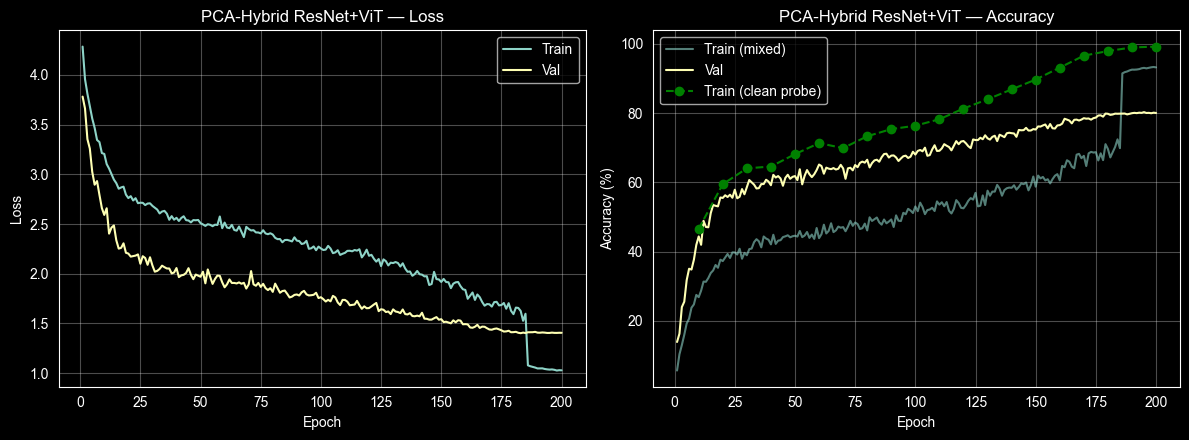

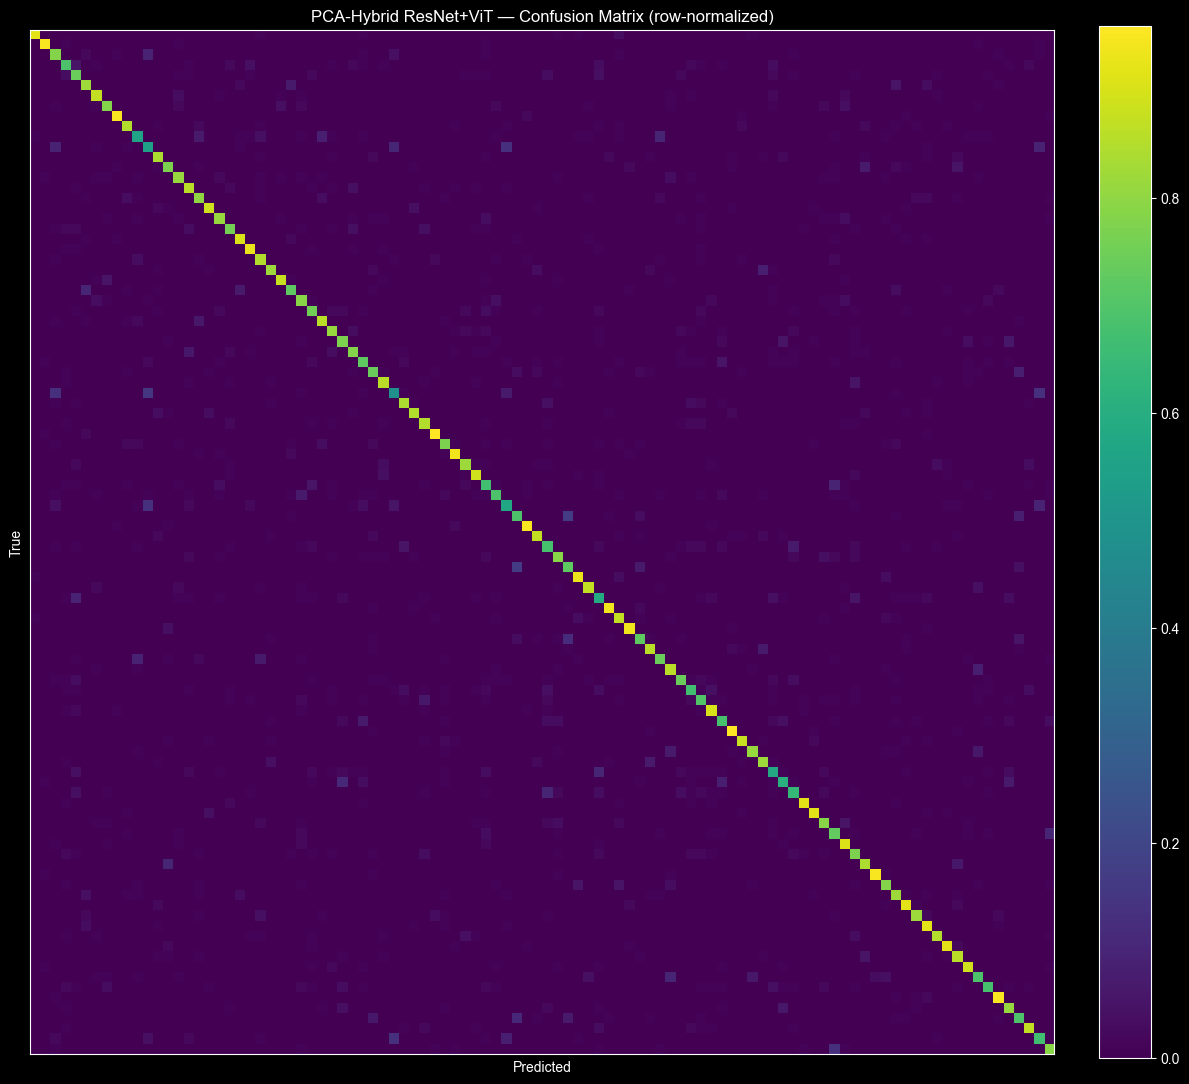

array([[0.92, 0.  , 0.  , ..., 0.  , 0.  , 0.  ],
       [0.  , 0.95, 0.  , ..., 0.  , 0.01, 0.  ],
       [0.  , 0.  , 0.78, ..., 0.  , 0.01, 0.  ],
       ...,
       [0.  , 0.  , 0.  , ..., 0.87, 0.  , 0.  ],
       [0.  , 0.  , 0.02, ..., 0.  , 0.67, 0.  ],
       [0.  , 0.  , 0.01, ..., 0.  , 0.  , 0.79]], shape=(100, 100))

In [7]:
class_names = test_set.classes

if "all_results" not in dir():
    all_results = {}

metrics = evaluate_model(model, test_loader, class_names, model_name="PCA-Hybrid ResNet+ViT")
all_results["PCA-Hybrid ResNet+ViT"] = metrics
plot_training_curves(history, "PCA-Hybrid ResNet+ViT")
plot_confusion_matrix(metrics["y_true"], metrics["y_pred"], class_names, "PCA-Hybrid ResNet+ViT")

In [9]:
"""
Flowers102 → PCA-initialized Hybrid ResNet+ViT
======================================================================

Recipe (unchanged from the CIFAR baseline apart from image size/batch):
  • PCA-initialized 5×5 stem (64 filters from 5×5×3 colour patches)
  • SGD + Nesterov, lr 0.1, cosine schedule, weight decay 5e-4
  • RandAugment + RandomErasing + Mixup/CutMix (mixing OFF for last epochs)
  • Label smoothing 0.1, AMP for speed
  • Clean train-accuracy probe every N epochs (mixup makes the running
    train metric meaningless -- this gives you the real number)
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, ConcatDataset
import torchvision
import torchvision.transforms as transforms
import numpy as np
import random, math, time

# ─────────────────────────────────────────────
#  0.  DEVICE / SEED
# ─────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Using device: {device}")
if device.type == "cuda":
    print(f"[INFO] GPU : {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)

# ─────────────────────────────────────────────
#  HYPER-PARAMETERS
# ─────────────────────────────────────────────
NUM_CLASSES   = 102
IMG_SIZE      = 64          # Flowers102 photos are resized/cropped to this
BATCH_SIZE    = 32          # small on purpose -- only ~2,040 training images
EPOCHS        = 200         # epochs are cheap (few images) so more passes is fine
NO_MIX_LAST   = 20          # disable mixup/cutmix for the final N epochs
BASE_LR       = 0.1
WEIGHT_DECAY  = 5e-4
LABEL_SMOOTH  = 0.1
WARMUP_EPOCHS = 5

MIX_PROB      = 0.5
MIXUP_ALPHA   = 0.2
CUTMIX_ALPHA  = 1.0

STEM_K        = 5           # PCA-initialized stem kernel (PCANet heritage)
STEM_FILTERS  = 64          # ≤ 75 (= 5*5*3 patch dimensionality)
N_FIT_IMAGES  = 1500        # capped to fit within the ~2,040-image train pool
N_FIT_PATCHES = 150_000

# --- transformer back-end hyperparameters ---
EMBED_DIM     = 128         # token dim fed into transformer blocks
TRANSFORMER_DEPTH = 6       # number of transformer encoder blocks
TRANSFORMER_HEADS = 8
TRANSFORMER_DROP  = 0.1

TRAIN_PROBE_EVERY = 10      # epochs between clean train-acc measurements

DATA_DIR = "./data"

# Flowers102 has no CIFAR-style official mean/std; ImageNet stats are the
# standard stand-in for natural-photo datasets of this kind.
FLOWERS_MEAN = (0.485, 0.456, 0.406)
FLOWERS_STD  = (0.229, 0.224, 0.225)

# ─────────────────────────────────────────────
#  1.  DATA
# ─────────────────────────────────────────────
print("\n[STEP 1] Loading Flowers102 …")

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandAugment(num_ops=2, magnitude=8),
    transforms.ToTensor(),
    transforms.Normalize(FLOWERS_MEAN, FLOWERS_STD),
    transforms.RandomErasing(p=0.25),
])
plain_tf = transforms.Compose([
    transforms.Resize(int(IMG_SIZE * 1.15)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(FLOWERS_MEAN, FLOWERS_STD),
])

# torchvision's Flowers102 splits are inverted vs. most datasets:
# "train"=1,020 imgs, "val"=1,020 imgs, "test"=6,149 imgs. We combine
# train+val for actual training and use the large "test" split to validate.
train_split_aug = torchvision.datasets.Flowers102(DATA_DIR, split="train", download=True, transform=train_tf)
val_split_aug   = torchvision.datasets.Flowers102(DATA_DIR, split="val",   download=True, transform=train_tf)
train_set = ConcatDataset([train_split_aug, val_split_aug])

train_split_plain = torchvision.datasets.Flowers102(DATA_DIR, split="train", download=True, transform=plain_tf)
val_split_plain   = torchvision.datasets.Flowers102(DATA_DIR, split="val",   download=True, transform=plain_tf)
probe_set = ConcatDataset([train_split_plain, val_split_plain])   # clean-accuracy probe pool
fit_set   = ConcatDataset([train_split_plain, val_split_plain])   # PCA patch-fitting pool

test_set  = torchvision.datasets.Flowers102(DATA_DIR, split="test", download=True, transform=plain_tf)

# probe pool is already small (2,040 imgs) so we just use all of it, no subsetting
probe_loader = DataLoader(probe_set, batch_size=128, shuffle=False,
                          num_workers=2, pin_memory=True)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=False,
                          persistent_workers=True)
test_loader  = DataLoader(test_set, batch_size=256, shuffle=False,
                          num_workers=2, pin_memory=True)

# ─────────────────────────────────────────────
#  2.  PCA STEM INITIALIZATION  (PCANet heritage)
# ─────────────────────────────────────────────
print("\n[STEP 2] Fitting PCA filters for the stem conv …")

def extract_patches(images, k, pad):
    p = F.unfold(images, kernel_size=k, padding=pad)
    return p.transpose(1, 2).reshape(-1, p.size(1))

@torch.no_grad()
def fit_pca_stem(num_filters, k):
    idx  = torch.randperm(len(fit_set))[:N_FIT_IMAGES]
    imgs = torch.stack([fit_set[i][0] for i in idx.tolist()])   # normalized images
    N, HW = imgs.size(0), imgs.size(2) * imgs.size(3)
    frac = min(1.0, N_FIT_PATCHES / (N * HW))
    chunks = []
    for i in range(0, N, 256):
        p = extract_patches(imgs[i:i+256], k, k // 2)
        chunks.append(p[torch.rand(p.size(0)) < frac])
    patches = torch.cat(chunks, 0)
    patches = patches - patches.mean(dim=1, keepdim=True)
    patches = patches - patches.mean(dim=0, keepdim=True)
    _, S, Vh = torch.linalg.svd(patches, full_matrices=False)
    W = Vh[:num_filters].view(num_filters, 3, k, k).contiguous()
    # scale so activations start with sane variance (match Kaiming magnitude)
    W = W * math.sqrt(2.0 / (3 * k * k)) / (W.std() + 1e-8) * 0.5
    return W

W_stem = fit_pca_stem(STEM_FILTERS, STEM_K)
print(f"  PCA stem bank: {tuple(W_stem.shape)} (trainable from this init)")

# ─────────────────────────────────────────────
#  3.  MODEL — Hybrid: PCA stem + ResNet stages + Transformer blocks
# ─────────────────────────────────────────────
class BasicBlock(nn.Module):
    expansion = 1
    def __init__(self, cin, cout, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(cin, cout, 3, stride, 1, bias=False)
        self.bn1   = nn.BatchNorm2d(cout)
        self.conv2 = nn.Conv2d(cout, cout, 3, 1, 1, bias=False)
        self.bn2   = nn.BatchNorm2d(cout)
        self.short = nn.Sequential()
        if stride != 1 or cin != cout:
            self.short = nn.Sequential(
                nn.Conv2d(cin, cout, 1, stride, bias=False),
                nn.BatchNorm2d(cout))
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)), inplace=True)
        out = self.bn2(self.conv2(out))
        return F.relu(out + self.short(x), inplace=True)


class TransformerBlock(nn.Module):
    """Pre-LN transformer encoder block (standard ViT-style block)."""
    def __init__(self, dim, heads, mlp_ratio=4.0, drop=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = nn.MultiheadAttention(dim, heads, dropout=drop, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden), nn.GELU(), nn.Dropout(drop),
            nn.Linear(hidden, dim), nn.Dropout(drop))
    def forward(self, x):
        a, _ = self.attn(self.norm1(x), self.norm1(x), self.norm1(x), need_weights=False)
        x = x + a
        x = x + self.mlp(self.norm2(x))
        return x


class PCAHybridResNetViT(nn.Module):
    """
    Stem + layer1/layer2 from ResNet (conv inductive bias for local features),
    then transformer blocks over the resulting feature-map tokens
    (global attention for higher-level structure) instead of layer3/layer4.

    Flow (IMG_SIZE=64):
      [3,64,64] --PCA stem--> [64,64,64] --layer1(stride2)--> [64,32,32]
                --layer2(stride2)--> [128,16,16] --1x1 proj--> [embed_dim,16,16]
                --flatten to 256 tokens + CLS + pos_embed-->
                --N x TransformerBlock--> LayerNorm --> CLS token --> FC

    Note: layer1 downsamples here (stride 2, vs. stride 1 in the CIFAR
    version) so a 64x64 input still lands on a 16x16 = 256-token map
    before the transformer -- keeping attention compute identical to
    the original CIFAR script regardless of the larger input images.
    """
    def __init__(self, stem_init, num_classes=102,
                 embed_dim=EMBED_DIM, depth=TRANSFORMER_DEPTH,
                 heads=TRANSFORMER_HEADS, drop=TRANSFORMER_DROP):
        super().__init__()
        nstem = stem_init.size(0)

        # --- conv front-end (PCA-initialized stem + first two ResNet stages) ---
        self.stem = nn.Conv2d(3, nstem, STEM_K, 1, STEM_K // 2, bias=False)
        with torch.no_grad():
            self.stem.weight.copy_(stem_init)          # PCA init, fully trainable
        self.bn0 = nn.BatchNorm2d(nstem)
        self.layer1 = self._make(nstem, 64,  2, 2)      # [64, 32, 32]
        self.layer2 = self._make(64,  128, 2, 2)         # [128, 16, 16]

        # --- transformer back-end (replaces layer3 / layer4) ---
        self.proj = nn.Conv2d(128, embed_dim, kernel_size=1)   # channel projection
        n_tokens = 16 * 16   # spatial size after layer1+layer2 downsampling
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, n_tokens + 1, embed_dim))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        self.pos_drop = nn.Dropout(drop)
        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, heads, drop=drop) for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def _make(self, cin, cout, blocks, stride):
        layers = [BasicBlock(cin, cout, stride)]
        layers += [BasicBlock(cout, cout) for _ in range(blocks - 1)]
        return nn.Sequential(*layers)

    def forward(self, x):
        x = F.relu(self.bn0(self.stem(x)), inplace=True)
        x = self.layer1(x)
        x = self.layer2(x)                 # [B, 128, 16, 16]
        x = self.proj(x)                   # [B, embed_dim, 16, 16]
        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)   # [B, 256, embed_dim] tokens
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1) + self.pos_embed
        x = self.pos_drop(x)
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)
        return self.head(x[:, 0])          # classify from CLS token


print("\n[STEP 3] Building model …")
model = PCAHybridResNetViT(W_stem, NUM_CLASSES,
                            embed_dim=EMBED_DIM, depth=TRANSFORMER_DEPTH,
                            heads=TRANSFORMER_HEADS, drop=TRANSFORMER_DROP).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  Trainable parameters: {n_params:,}")

# ─────────────────────────────────────────────
#  4.  MIXUP / CUTMIX
# ─────────────────────────────────────────────
def mixup_cutmix(x, y, enabled=True):
    if not enabled or random.random() > MIX_PROB:
        return x, y, y, 1.0
    perm = torch.randperm(x.size(0), device=x.device)
    if random.random() < 0.5:
        lam = float(np.random.beta(CUTMIX_ALPHA, CUTMIX_ALPHA))
        H, W = x.size(2), x.size(3)
        rh, rw = int(H * math.sqrt(1 - lam)), int(W * math.sqrt(1 - lam))
        cy, cx = random.randint(0, H - 1), random.randint(0, W - 1)
        y1, y2 = max(cy - rh // 2, 0), min(cy + rh // 2, H)
        x1, x2 = max(cx - rw // 2, 0), min(cx + rw // 2, W)
        x = x.clone()
        x[:, :, y1:y2, x1:x2] = x[perm, :, y1:y2, x1:x2]
        lam = 1.0 - ((x2 - x1) * (y2 - y1) / (H * W))
    else:
        lam = float(np.random.beta(MIXUP_ALPHA, MIXUP_ALPHA))
        x = lam * x + (1 - lam) * x[perm]
    return x, y, y[perm], lam

# ─────────────────────────────────────────────
#  5.  LOSS / OPTIMISER / SCHEDULER / AMP
# ─────────────────────────────────────────────
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)

# no weight decay on BN / LayerNorm params or biases
decay, no_decay = [], []
for n, p in model.named_parameters():
    (no_decay if p.ndim <= 1 else decay).append(p)
optimizer = optim.SGD([
    {"params": decay, "weight_decay": WEIGHT_DECAY},
    {"params": no_decay, "weight_decay": 0.0},
], lr=BASE_LR, momentum=0.9, nesterov=True)

steps_per_epoch = len(train_loader)
total_steps  = EPOCHS * steps_per_epoch
warmup_steps = WARMUP_EPOCHS * steps_per_epoch

def lr_at(step):
    if step < warmup_steps:
        return BASE_LR * (step + 1) / warmup_steps
    t = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return 0.5 * BASE_LR * (1 + math.cos(math.pi * t))

scaler = torch.cuda.amp.GradScaler(enabled=device.type == "cuda")

# ─────────────────────────────────────────────
#  6.  TRAIN / EVAL
# ─────────────────────────────────────────────
@torch.no_grad()
def evaluate(loader):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    for imgs, targets in loader:
        imgs, targets = imgs.to(device, non_blocking=True), targets.to(device, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=device.type == "cuda"):
            out = model(imgs)
            loss = criterion(out, targets)
        loss_sum += loss.item() * imgs.size(0)
        correct  += out.argmax(1).eq(targets).sum().item()
        total    += imgs.size(0)
    return loss_sum / total, 100.0 * correct / total

def train_one_epoch(epoch, global_step, mix_enabled):
    model.train()
    loss_sum, correct, total = 0.0, 0, 0
    for imgs, targets in train_loader:
        lr = lr_at(global_step)
        for g in optimizer.param_groups:
            g["lr"] = lr
        imgs    = imgs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        imgs, ya, yb, lam = mixup_cutmix(imgs, targets, mix_enabled)

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=device.type == "cuda"):
            out  = model(imgs)
            loss = lam * criterion(out, ya) + (1 - lam) * criterion(out, yb)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        loss_sum += loss.item() * imgs.size(0)
        correct  += out.argmax(1).eq(ya).sum().item()
        total    += imgs.size(0)
        global_step += 1
    return loss_sum / total, 100.0 * correct / total, global_step

print("\n[STEP 4] Training …  (Acc* is approximate while mixing is on)\n")
best_acc, global_step = 0.0, 0
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [],
           "clean_train_acc": {}}

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    mix_enabled = epoch <= EPOCHS - NO_MIX_LAST
    tr_loss, tr_acc, global_step = train_one_epoch(epoch, global_step, mix_enabled)
    va_loss, va_acc = evaluate(test_loader)

    history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss);   history["val_acc"].append(va_acc)

    msg = (f"Epoch {epoch:3d}/{EPOCHS} | Train Loss {tr_loss:.4f} Acc* {tr_acc:5.2f}% | "
           f"Val Loss {va_loss:.4f} Acc {va_acc:5.2f}% | "
           f"LR {lr_at(global_step):.4f} | mix={'on' if mix_enabled else 'OFF'} | "
           f"{time.time()-t0:.1f}s")

    if epoch % TRAIN_PROBE_EVERY == 0 or epoch == EPOCHS:
        _, clean_tr = evaluate(probe_loader)
        history["clean_train_acc"][epoch] = clean_tr
        msg += f" | CLEAN train acc: {clean_tr:.2f}%"
    print(msg)

    if va_acc > best_acc:
        best_acc = va_acc
        torch.save({"epoch": epoch, "model_state": model.state_dict(),
                    "val_acc": va_acc,
                    "config": {"stem_k": STEM_K, "stem_filters": STEM_FILTERS,
                               "embed_dim": EMBED_DIM, "depth": TRANSFORMER_DEPTH,
                               "heads": TRANSFORMER_HEADS,
                               "num_classes": NUM_CLASSES, "img_size": IMG_SIZE}},
                   "best_pca_hybrid_resnet_vit_flowers102.pth")
        print(f"  ✔ New best model saved (val acc = {va_acc:.2f}%)")

print(f"\n[DONE] Best validation accuracy: {best_acc:.2f}%")
print("Clean train accuracy probes:", history["clean_train_acc"])

# ─────────────────────────────────────────────
#  7.  INFERENCE
# ─────────────────────────────────────────────
@torch.no_grad()
def predict_single(img_tensor_chw):
    """[3,IMG_SIZE,IMG_SIZE] image in [0,1] → class index 0–101.
    Resize/center-crop to IMG_SIZE before calling this if your image
    isn't already that size."""
    ckpt = torch.load("best_pca_hybrid_resnet_vit_flowers102.pth", map_location=device)
    model.load_state_dict(ckpt["model_state"])
    model.eval()
    x = transforms.functional.normalize(img_tensor_chw, FLOWERS_MEAN, FLOWERS_STD)
    return model(x.unsqueeze(0).to(device)).argmax(1).item()

[INFO] Using device: cuda
[INFO] GPU : NVIDIA GeForce RTX 3060

[STEP 1] Loading Flowers102 …

[STEP 2] Fitting PCA filters for the stem conv …
  PCA stem bank: (64, 3, 5, 5) (trainable from this init)

[STEP 3] Building model …
  Trainable parameters: 1,935,270

[STEP 4] Training …  (Acc* is approximate while mixing is on)



C:\Users\adnan\AppData\Local\Temp\ipykernel_8456\3298868529.py:343: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=device.type == "cuda")
C:\Users\adnan\AppData\Local\Temp\ipykernel_8456\3298868529.py:374: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=device.type == "cuda"):
C:\Users\adnan\AppData\Local\Temp\ipykernel_8456\3298868529.py:354: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=device.type == "cuda"):


Epoch   1/200 | Train Loss 4.7105 Acc*  0.88% | Val Loss 4.6037 Acc  2.89% | LR 0.0203 | mix=on | 20.9s
  ✔ New best model saved (val acc = 2.89%)
Epoch   2/200 | Train Loss 4.4686 Acc*  3.43% | Val Loss 4.4293 Acc  1.74% | LR 0.0403 | mix=on | 18.3s
Epoch   3/200 | Train Loss 4.3534 Acc*  4.17% | Val Loss 4.2034 Acc  5.58% | LR 0.0603 | mix=on | 16.2s
  ✔ New best model saved (val acc = 5.58%)
Epoch   4/200 | Train Loss 4.2311 Acc*  5.10% | Val Loss 4.1473 Acc  5.79% | LR 0.0803 | mix=on | 17.2s
  ✔ New best model saved (val acc = 5.79%)
Epoch   5/200 | Train Loss 4.1196 Acc*  4.90% | Val Loss 4.0399 Acc  7.45% | LR 0.1000 | mix=on | 15.8s
  ✔ New best model saved (val acc = 7.45%)
Epoch   6/200 | Train Loss 4.0529 Acc*  6.32% | Val Loss 3.9556 Acc  9.61% | LR 0.1000 | mix=on | 16.8s
  ✔ New best model saved (val acc = 9.61%)
Epoch   7/200 | Train Loss 4.0071 Acc*  8.48% | Val Loss 3.8353 Acc 10.52% | LR 0.1000 | mix=on | 16.6s
  ✔ New best model saved (val acc = 10.52%)
Epoch   8/200

In [12]:
# torchvision's Flowers102 has no built-in class-name list (unlike CIFAR100),
# so default to numeric labels. Swap in the Oxford cat_to_name mapping here
# if you have it and want real flower names in the report/confusion matrix.
class_names = [str(i) for i in range(NUM_CLASSES)]

In [13]:
ckpt = torch.load("best_pca_hybrid_resnet_vit_flowers102.pth", map_location=device)
model.load_state_dict(ckpt["model_state"])
print(f"Loaded best checkpoint: epoch {ckpt['epoch']}, val_acc={ckpt['val_acc']:.2f}%")

Loaded best checkpoint: epoch 193, val_acc=72.91%


C:\Users\adnan\AppData\Local\Temp\ipykernel_8456\1167014401.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load("best_pca_hybrid_resnet_vit_flowers102.pth"

C:\Users\adnan\AppData\Local\Temp\ipykernel_8456\1865012544.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=device.type == "cuda"):



PCA-Hybrid ResNet+ViT (Flowers102)
Top-1 accuracy: 72.91%   Top-5 accuracy: 88.57%
Weakest classes: 42 (24%), 73 (32%), 83 (32%), 3 (36%), 30 (38%)
Strongest classes: 99 (100%), 70 (100%), 65 (100%), 58 (100%), 60 (100%)


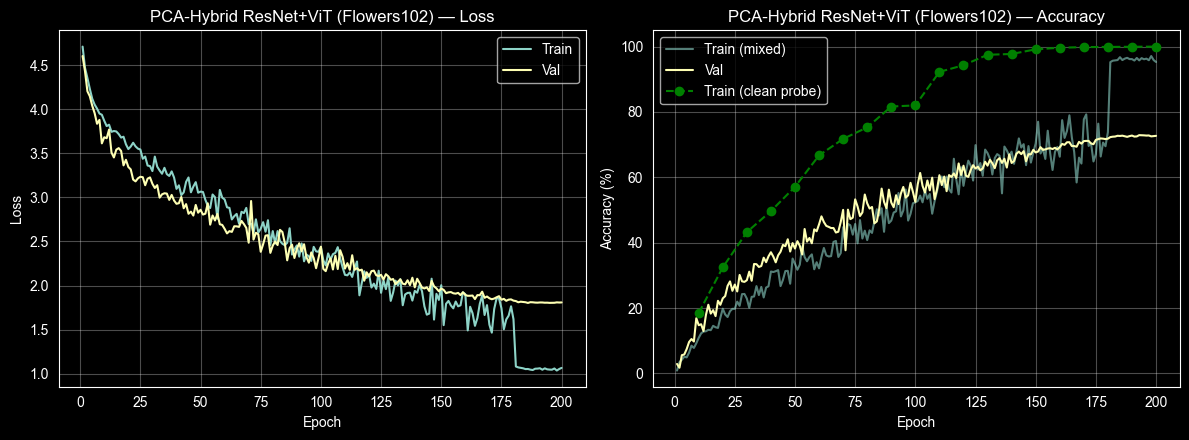

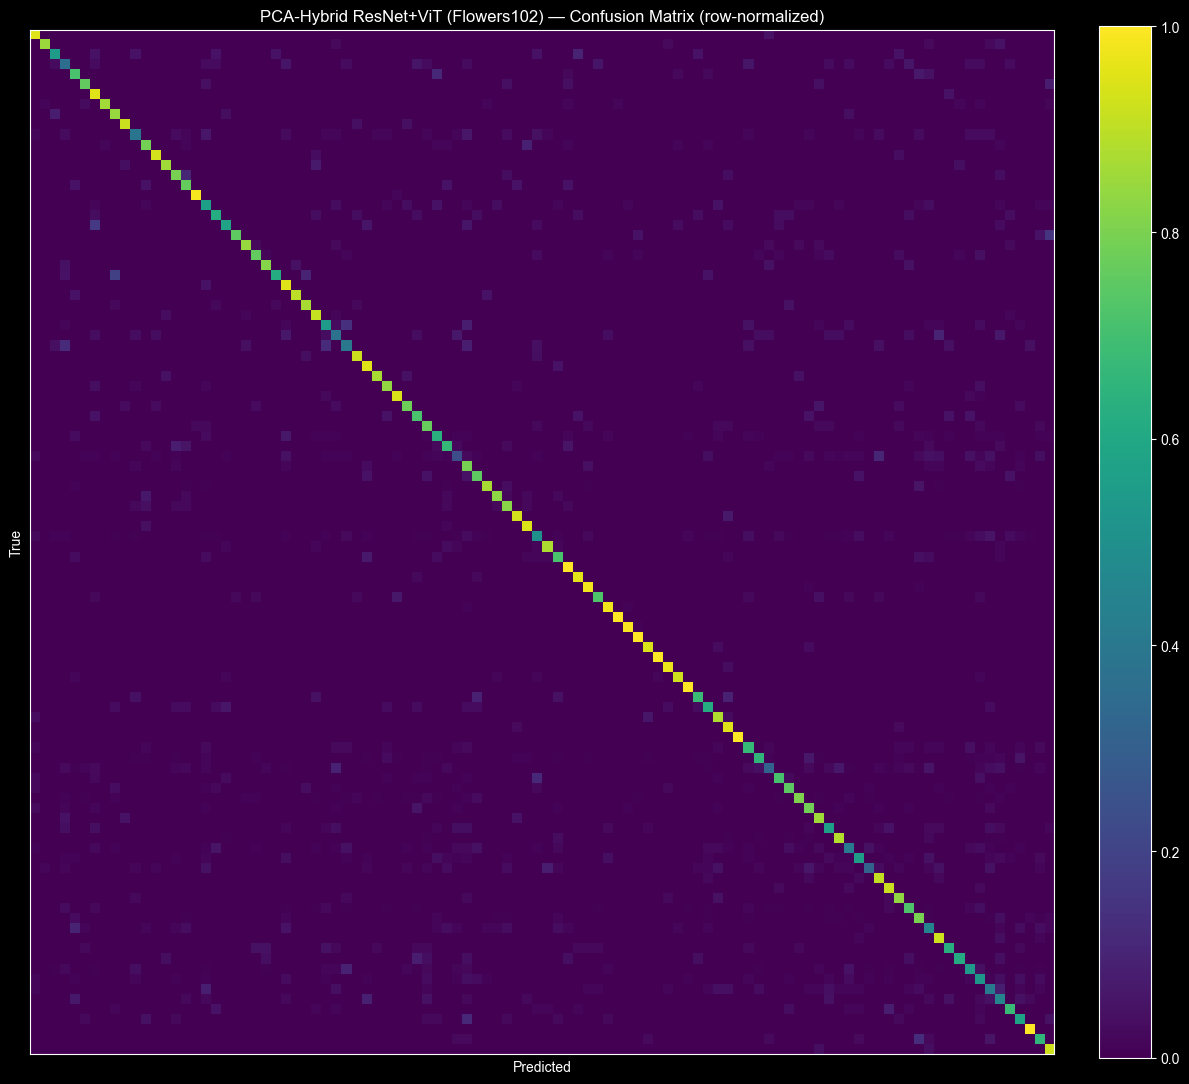

array([[0.95      , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.85      , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.55      , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 1.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.65789474,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.92857143]], shape=(102, 102))

In [14]:
if "all_results" not in dir():
    all_results = {}

metrics = evaluate_model(model, test_loader, class_names, model_name="PCA-Hybrid ResNet+ViT (Flowers102)")
all_results["PCA-Hybrid ResNet+ViT (Flowers102)"] = metrics
plot_training_curves(history, "PCA-Hybrid ResNet+ViT (Flowers102)")
plot_confusion_matrix(metrics["y_true"], metrics["y_pred"], class_names, "PCA-Hybrid ResNet+ViT (Flowers102)")

In [ ]:
"""
Tiny ImageNet (200 classes, 64x64) -> PCA-initialized Hybrid ResNet+ViT
======================================================================
Architecture (same hybrid idea as the CIFAR-100 version, with ONE extra
ResNet downsampling stage since Tiny ImageNet images are 64x64 -- double
the 32x32 of CIFAR-100):
  • PCA-initialized 5x5 stem conv (PCANet heritage, fully trainable)
  • ResNet BasicBlocks:
        layer1: 64ch  @ 64x64  (stride 1)
        layer2: 128ch @ 32x32  (stride 2)
        layer3: 256ch @ 16x16  (stride 2)   <-- NEW vs the CIFAR script
    The extra stage exists purely to keep the transformer token count at
    16x16 = 256, matching the CIFAR-100 version. Without it, a 64x64 input
    would leave layer2's output at 32x32 = 1024 tokens, which is ~16x more
    expensive for self-attention (cost grows with the square of token
    count) and ~4x more expensive for the per-token MLP.
  • Feature map from layer3 is projected and flattened into 256 tokens,
    then processed by N transformer encoder blocks (self-attention)
  • CLS token + learned positional embeddings, LayerNorm'd output -> FC head


Recipe (same strong-baseline recipe as the CIFAR-100 script, unchanged
except where the dataset forces a change -- crop padding scaled to the
larger image size, and normalization stats for Tiny ImageNet):
  • PCA-initialized 5x5 stem (64 filters from 5x5x3 colour patches)
  • Per-channel normalization (Tiny ImageNet mean/std)
  • SGD + Nesterov, lr 0.1, cosine schedule, weight decay 5e-4
  • RandAugment + RandomErasing + Mixup/CutMix (mixing OFF for last 15 epochs)
  • Label smoothing 0.1, AMP for speed, batch 128
  • Clean train-accuracy probe every 10 epochs

"""

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset
import torchvision.transforms as transforms
import numpy as np
import random, math, time, os, glob, zipfile, urllib.request
from PIL import Image

# ─────────────────────────────────────────────
#  0.  DEVICE / SEED
# ─────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Using device: {device}")
if device.type == "cuda":
    print(f"[INFO] GPU : {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)

# ─────────────────────────────────────────────
#  HYPER-PARAMETERS
# ─────────────────────────────────────────────
NUM_CLASSES   = 200         # Tiny ImageNet: 200 classes (vs CIFAR-100's 100)
IMG_SIZE      = 64          # Tiny ImageNet: 64x64 (vs CIFAR-100's 32x32)
BATCH_SIZE    = 128
EPOCHS        = 200
NO_MIX_LAST   = 15          # disable mixup/cutmix for the final N epochs
BASE_LR       = 0.1
WEIGHT_DECAY  = 5e-4
LABEL_SMOOTH  = 0.1
WARMUP_EPOCHS = 5

MIX_PROB      = 0.5
MIXUP_ALPHA   = 0.2
CUTMIX_ALPHA  = 1.0

STEM_K        = 5           # PCA-initialized stem kernel (PCANet heritage)
STEM_FILTERS  = 64          # ≤ 75 (= 5*5*3 patch dimensionality)
N_FIT_IMAGES  = 8000         # bumped up a bit vs CIFAR-100: 2x the classes
N_FIT_PATCHES = 200_000      # to fit, and more diverse patches to cover

# --- transformer back-end hyperparameters ---
EMBED_DIM     = 128         # token dim fed into transformer blocks
TRANSFORMER_DEPTH = 6       # number of transformer encoder blocks
TRANSFORMER_HEADS = 8
TRANSFORMER_DROP  = 0.1

TRAIN_PROBE_EVERY = 10      # epochs between clean train-acc measurements
TRAIN_PROBE_SIZE  = 10_000  # subset size for the probe (speed)

DATA_DIR = "./data"

TINY_IMAGENET_URL = "http://cs231n.stanford.edu/tiny-imagenet-200.zip"
TINY_IMAGENET_MEAN = (0.4802, 0.4481, 0.3975)
TINY_IMAGENET_STD  = (0.2302, 0.2265, 0.2262)

# ─────────────────────────────────────────────
#  1.  DATA  (Tiny ImageNet: download + custom Dataset classes)
# ─────────────────────────────────────────────
print("\n[STEP 1] Loading Tiny ImageNet …")

def download_tiny_imagenet(dest_dir=DATA_DIR):
    """Downloads and extracts tiny-imagenet-200.zip if not already present."""
    root = os.path.join(dest_dir, "tiny-imagenet-200")
    if os.path.exists(os.path.join(root, "wnids.txt")):
        return root
    os.makedirs(dest_dir, exist_ok=True)
    zip_path = os.path.join(dest_dir, "tiny-imagenet-200.zip")
    if not os.path.exists(zip_path):
        print("  Downloading tiny-imagenet-200.zip (~237 MB) …")
        urllib.request.urlretrieve(TINY_IMAGENET_URL, zip_path)
    print("  Extracting …")
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(dest_dir)
    return root


class TinyImageNetTrain(Dataset):
    """train/<wnid>/images/*.JPEG -- one folder per class."""
    def __init__(self, root, wnids, transform=None):
        self.transform = transform
        self.class_to_idx = {w: i for i, w in enumerate(wnids)}
        self.samples = []
        for wnid in wnids:
            img_dir = os.path.join(root, "train", wnid, "images")
            for path in glob.glob(os.path.join(img_dir, "*.JPEG")):
                self.samples.append((path, self.class_to_idx[wnid]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label


class TinyImageNetVal(Dataset):
    """
    val/images/*.JPEG + val_annotations.txt (filename -> wnid mapping).
    This is Tiny ImageNet's only labeled held-out split (the official
    "test" split ships without public labels), so it doubles as both
    the validation set during training and the final eval set here.
    """
    def __init__(self, root, wnids, transform=None):
        self.transform = transform
        class_to_idx = {w: i for i, w in enumerate(wnids)}
        ann_path = os.path.join(root, "val", "val_annotations.txt")
        img_dir = os.path.join(root, "val", "images")
        self.samples = []
        with open(ann_path) as f:
            for line in f:
                fname, wnid = line.strip().split("\t")[:2]
                self.samples.append((os.path.join(img_dir, fname), class_to_idx[wnid]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label


train_tf = transforms.Compose([
    transforms.RandomCrop(IMG_SIZE, padding=8, padding_mode="reflect"),
    transforms.RandomHorizontalFlip(),
    transforms.RandAugment(num_ops=2, magnitude=8),
    transforms.ToTensor(),
    transforms.Normalize(TINY_IMAGENET_MEAN, TINY_IMAGENET_STD),
    transforms.RandomErasing(p=0.25),
])
plain_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(TINY_IMAGENET_MEAN, TINY_IMAGENET_STD),
])

tiny_root = download_tiny_imagenet(DATA_DIR)
with open(os.path.join(tiny_root, "wnids.txt")) as f:
    WNIDS = [line.strip() for line in f if line.strip()]
print(f"  {len(WNIDS)} classes found")

train_set = TinyImageNetTrain(tiny_root, WNIDS, transform=train_tf)
probe_set = TinyImageNetTrain(tiny_root, WNIDS, transform=plain_tf)
test_set  = TinyImageNetVal(tiny_root, WNIDS, transform=plain_tf)
fit_set   = TinyImageNetTrain(tiny_root, WNIDS, transform=plain_tf)
print(f"  train={len(train_set)}  val={len(test_set)}")

probe_idx    = torch.randperm(len(probe_set))[:TRAIN_PROBE_SIZE].tolist()
probe_loader = DataLoader(Subset(probe_set, probe_idx), batch_size=256,
                          shuffle=False, num_workers=2, pin_memory=True)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=True,
                          persistent_workers=True)
test_loader  = DataLoader(test_set, batch_size=256, shuffle=False,
                          num_workers=2, pin_memory=True)

# ─────────────────────────────────────────────
#  2.  PCA STEM INITIALIZATION  (PCANet heritage)
# ─────────────────────────────────────────────
print("\n[STEP 2] Fitting PCA filters for the stem conv …")

def extract_patches(images, k, pad):
    p = F.unfold(images, kernel_size=k, padding=pad)
    return p.transpose(1, 2).reshape(-1, p.size(1))

@torch.no_grad()
def fit_pca_stem(num_filters, k):
    idx  = torch.randperm(len(fit_set))[:N_FIT_IMAGES]
    imgs = torch.stack([fit_set[i][0] for i in idx.tolist()])   # normalized images
    N, HW = imgs.size(0), imgs.size(2) * imgs.size(3)
    frac = min(1.0, N_FIT_PATCHES / (N * HW))
    chunks = []
    for i in range(0, N, 256):
        p = extract_patches(imgs[i:i+256], k, k // 2)
        chunks.append(p[torch.rand(p.size(0)) < frac])
    patches = torch.cat(chunks, 0)
    patches = patches - patches.mean(dim=1, keepdim=True)
    patches = patches - patches.mean(dim=0, keepdim=True)
    _, S, Vh = torch.linalg.svd(patches, full_matrices=False)
    W = Vh[:num_filters].view(num_filters, 3, k, k).contiguous()
    # scale so activations start with sane variance (match Kaiming magnitude)
    W = W * math.sqrt(2.0 / (3 * k * k)) / (W.std() + 1e-8) * 0.5
    return W

W_stem = fit_pca_stem(STEM_FILTERS, STEM_K)
print(f"  PCA stem bank: {tuple(W_stem.shape)} (trainable from this init)")

# ─────────────────────────────────────────────
#  3.  MODEL — Hybrid: PCA stem + ResNet stages + Transformer blocks
# ─────────────────────────────────────────────
class BasicBlock(nn.Module):
    expansion = 1
    def __init__(self, cin, cout, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(cin, cout, 3, stride, 1, bias=False)
        self.bn1   = nn.BatchNorm2d(cout)
        self.conv2 = nn.Conv2d(cout, cout, 3, 1, 1, bias=False)
        self.bn2   = nn.BatchNorm2d(cout)
        self.short = nn.Sequential()
        if stride != 1 or cin != cout:
            self.short = nn.Sequential(
                nn.Conv2d(cin, cout, 1, stride, bias=False),
                nn.BatchNorm2d(cout))
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)), inplace=True)
        out = self.bn2(self.conv2(out))
        return F.relu(out + self.short(x), inplace=True)


class TransformerBlock(nn.Module):
    """Pre-LN transformer encoder block (standard ViT-style block)."""
    def __init__(self, dim, heads, mlp_ratio=4.0, drop=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = nn.MultiheadAttention(dim, heads, dropout=drop, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden), nn.GELU(), nn.Dropout(drop),
            nn.Linear(hidden, dim), nn.Dropout(drop))
    def forward(self, x):
        a, _ = self.attn(self.norm1(x), self.norm1(x), self.norm1(x), need_weights=False)
        x = x + a
        x = x + self.mlp(self.norm2(x))
        return x


class PCAHybridResNetViT(nn.Module):
    """
    Stem + layer1/layer2/layer3 from ResNet (conv inductive bias for local
    features), then transformer blocks over the resulting feature-map
    tokens (global attention for higher-level structure).

    Flow (64x64 Tiny ImageNet input):
      [3,64,64]  --PCA stem-->  [64,64,64]  --layer1-->  [64,64,64]
                 --layer2-->    [128,32,32] --layer3-->   [256,16,16]
                 --1x1 proj-->  [embed_dim,16,16]
                 --flatten to 256 tokens + CLS + pos_embed-->
                 --N x TransformerBlock--> LayerNorm --> CLS token --> FC

    (layer3 is the one addition vs. the CIFAR-100 version -- see the
    module docstring at the top of this file for why.)
    """
    def __init__(self, stem_init, num_classes=200,
                 embed_dim=EMBED_DIM, depth=TRANSFORMER_DEPTH,
                 heads=TRANSFORMER_HEADS, drop=TRANSFORMER_DROP):
        super().__init__()
        nstem = stem_init.size(0)

        # --- conv front-end (PCA-initialized stem + three ResNet stages) ---
        self.stem = nn.Conv2d(3, nstem, STEM_K, 1, STEM_K // 2, bias=False)
        with torch.no_grad():
            self.stem.weight.copy_(stem_init)          # PCA init, fully trainable
        self.bn0 = nn.BatchNorm2d(nstem)
        self.layer1 = self._make(nstem, 64,  2, 1)      # [64,  64, 64]
        self.layer2 = self._make(64,  128, 2, 2)         # [128, 32, 32]
        self.layer3 = self._make(128, 256, 2, 2)         # [256, 16, 16]

        # --- transformer back-end ---
        self.proj = nn.Conv2d(256, embed_dim, kernel_size=1)   # channel projection
        n_tokens = 16 * 16   # spatial size after layer3 downsampling
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, n_tokens + 1, embed_dim))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        self.pos_drop = nn.Dropout(drop)
        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, heads, drop=drop) for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def _make(self, cin, cout, blocks, stride):
        layers = [BasicBlock(cin, cout, stride)]
        layers += [BasicBlock(cout, cout) for _ in range(blocks - 1)]
        return nn.Sequential(*layers)

    def forward(self, x):
        x = F.relu(self.bn0(self.stem(x)), inplace=True)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)                 # [B, 256, 16, 16]
        x = self.proj(x)                   # [B, embed_dim, 16, 16]
        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)   # [B, 256, embed_dim] tokens
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1) + self.pos_embed
        x = self.pos_drop(x)
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)
        return self.head(x[:, 0])          # classify from CLS token


print("\n[STEP 3] Building model …")
model = PCAHybridResNetViT(W_stem, NUM_CLASSES,
                            embed_dim=EMBED_DIM, depth=TRANSFORMER_DEPTH,
                            heads=TRANSFORMER_HEADS, drop=TRANSFORMER_DROP).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  Trainable parameters: {n_params:,}")

# ─────────────────────────────────────────────
#  4.  MIXUP / CUTMIX
# ─────────────────────────────────────────────
def mixup_cutmix(x, y, enabled=True):
    if not enabled or random.random() > MIX_PROB:
        return x, y, y, 1.0
    perm = torch.randperm(x.size(0), device=x.device)
    if random.random() < 0.5:
        lam = float(np.random.beta(CUTMIX_ALPHA, CUTMIX_ALPHA))
        H, W = x.size(2), x.size(3)
        rh, rw = int(H * math.sqrt(1 - lam)), int(W * math.sqrt(1 - lam))
        cy, cx = random.randint(0, H - 1), random.randint(0, W - 1)
        y1, y2 = max(cy - rh // 2, 0), min(cy + rh // 2, H)
        x1, x2 = max(cx - rw // 2, 0), min(cx + rw // 2, W)
        x = x.clone()
        x[:, :, y1:y2, x1:x2] = x[perm, :, y1:y2, x1:x2]
        lam = 1.0 - ((x2 - x1) * (y2 - y1) / (H * W))
    else:
        lam = float(np.random.beta(MIXUP_ALPHA, MIXUP_ALPHA))
        x = lam * x + (1 - lam) * x[perm]
    return x, y, y[perm], lam

# ─────────────────────────────────────────────
#  5.  LOSS / OPTIMISER / SCHEDULER / AMP
# ─────────────────────────────────────────────
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)

# no weight decay on BN / LayerNorm params or biases
decay, no_decay = [], []
for n, p in model.named_parameters():
    (no_decay if p.ndim <= 1 else decay).append(p)
optimizer = optim.SGD([
    {"params": decay, "weight_decay": WEIGHT_DECAY},
    {"params": no_decay, "weight_decay": 0.0},
], lr=BASE_LR, momentum=0.9, nesterov=True)

steps_per_epoch = len(train_loader)
total_steps  = EPOCHS * steps_per_epoch
warmup_steps = WARMUP_EPOCHS * steps_per_epoch

def lr_at(step):
    if step < warmup_steps:
        return BASE_LR * (step + 1) / warmup_steps
    t = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return 0.5 * BASE_LR * (1 + math.cos(math.pi * t))

scaler = torch.cuda.amp.GradScaler(enabled=device.type == "cuda")

# ─────────────────────────────────────────────
#  6.  TRAIN / EVAL
# ─────────────────────────────────────────────
@torch.no_grad()
def evaluate(loader):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    for imgs, targets in loader:
        imgs, targets = imgs.to(device, non_blocking=True), targets.to(device, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=device.type == "cuda"):
            out = model(imgs)
            loss = criterion(out, targets)
        loss_sum += loss.item() * imgs.size(0)
        correct  += out.argmax(1).eq(targets).sum().item()
        total    += imgs.size(0)
    return loss_sum / total, 100.0 * correct / total

def train_one_epoch(epoch, global_step, mix_enabled):
    model.train()
    loss_sum, correct, total = 0.0, 0, 0
    for imgs, targets in train_loader:
        lr = lr_at(global_step)
        for g in optimizer.param_groups:
            g["lr"] = lr
        imgs    = imgs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        imgs, ya, yb, lam = mixup_cutmix(imgs, targets, mix_enabled)

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=device.type == "cuda"):
            out  = model(imgs)
            loss = lam * criterion(out, ya) + (1 - lam) * criterion(out, yb)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        loss_sum += loss.item() * imgs.size(0)
        correct  += out.argmax(1).eq(ya).sum().item()
        total    += imgs.size(0)
        global_step += 1
    return loss_sum / total, 100.0 * correct / total, global_step

print("\n[STEP 4] Training …  (Acc* is approximate while mixing is on)\n")
best_acc, global_step = 0.0, 0
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [],
           "clean_train_acc": {}}

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    mix_enabled = epoch <= EPOCHS - NO_MIX_LAST
    tr_loss, tr_acc, global_step = train_one_epoch(epoch, global_step, mix_enabled)
    va_loss, va_acc = evaluate(test_loader)

    history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss);   history["val_acc"].append(va_acc)

    msg = (f"Epoch {epoch:3d}/{EPOCHS} | Train Loss {tr_loss:.4f} Acc* {tr_acc:5.2f}% | "
           f"Val Loss {va_loss:.4f} Acc {va_acc:5.2f}% | "
           f"LR {lr_at(global_step):.4f} | mix={'on' if mix_enabled else 'OFF'} | "
           f"{time.time()-t0:.1f}s")

    if epoch % TRAIN_PROBE_EVERY == 0 or epoch == EPOCHS:
        _, clean_tr = evaluate(probe_loader)
        history["clean_train_acc"][epoch] = clean_tr
        msg += f" | CLEAN train acc: {clean_tr:.2f}%"
    print(msg)

    if va_acc > best_acc:
        best_acc = va_acc
        torch.save({"epoch": epoch, "model_state": model.state_dict(),
                    "val_acc": va_acc,
                    "wnids": WNIDS,
                    "config": {"stem_k": STEM_K, "stem_filters": STEM_FILTERS,
                               "embed_dim": EMBED_DIM, "depth": TRANSFORMER_DEPTH,
                               "heads": TRANSFORMER_HEADS}},
                   "best_pca_hybrid_resnet_vit_tinyimagenet.pth")
        print(f"  ✔ New best model saved (val acc = {va_acc:.2f}%)")

print(f"\n[DONE] Best validation accuracy: {best_acc:.2f}%")
print("Clean train accuracy probes:", history["clean_train_acc"])

# ─────────────────────────────────────────────
#  7.  INFERENCE
# ─────────────────────────────────────────────
@torch.no_grad()
def predict_single(img_tensor_chw):
    """[3,64,64] image in [0,1] → class index 0–199 (index into WNIDS)."""
    ckpt = torch.load("best_pca_hybrid_resnet_vit_tinyimagenet.pth", map_location=device)
    model.load_state_dict(ckpt["model_state"])
    model.eval()
    x = transforms.functional.normalize(img_tensor_chw, TINY_IMAGENET_MEAN, TINY_IMAGENET_STD)
    return model(x.unsqueeze(0).to(device)).argmax(1).item()

[INFO] Using device: cuda
[INFO] GPU : NVIDIA GeForce RTX 3060

[STEP 1] Loading Tiny ImageNet …
  200 classes found
  train=100000  val=10000

[STEP 2] Fitting PCA filters for the stem conv …
  PCA stem bank: (64, 3, 5, 5) (trainable from this init)

[STEP 3] Building model …
  Trainable parameters: 4,059,784

[STEP 4] Training …  (Acc* is approximate while mixing is on)



C:\Users\adnan\AppData\Local\Temp\ipykernel_8456\715706453.py:413: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=device.type == "cuda")
